# Teleco Customer Churn Analysis
**Student Name:** Kevin Thomas Jacob  
**Date:** March 10, 2026

---

## 1. Project Introduction
The goal of this project is to analyze customer behavior at a telecommunications company to predict **churn**—the likelihood of a customer leaving the service. By identifying high-risk customers, the business can implement proactive retention strategies.

### Key Objectives:
* **Exploratory Data Analysis (EDA):** Identify patterns in customer demographics and service usage.
* **Feature Engineering:** Process categorical variables and service types for modeling.
* **Predictive Modeling:** Use machine learning to classify customers as likely to churn or stay.
* **Feature Importance:** Determine which factors (e.g., contract type, monthly charges) most influence churn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('Teleco_customer_churn.csv')

# Basic Info and Target Check
print(f"Dataset Dimensions: {df.shape}")
print(df.info())

Dataset Dimensions: (7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object

## 2. Exploratory Data Analysis (EDA)
Understanding the distribution of our target variable is the first step. In this dataset, the **Churn Rate is approximately 26.54%**. We will visualize this distribution to understand the class balance.

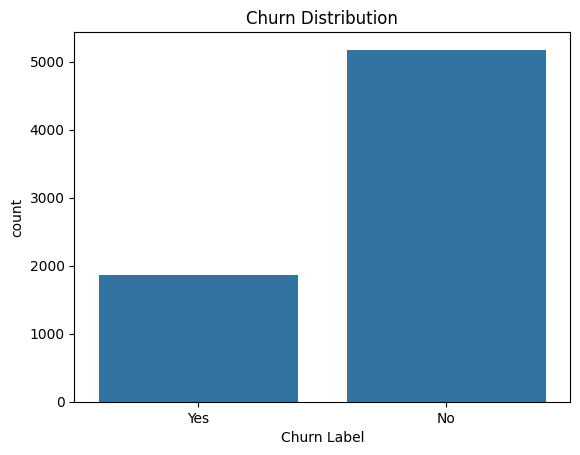

Churn Rate: 26.54%


In [ ]:
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.show()
print(f"Churn Rate: {df['Churn Label'].value_counts(normalize=True)['Yes']:.2%}")

## 3. Data Preprocessing
We must convert categorical text data into numeric format using dummy variables and split the data into training and testing sets.

In [ ]:
# Drop non-predictive columns and the target
X = df.drop(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Label', 'Churn Value', 'Churn Reason'],
            axis=1, errors='ignore')

# Convert categories to numbers
X = pd.get_dummies(X, drop_first=True)
y = df['Churn Value'] # Numeric target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## 4. Model Training
We use a Random Forest Classifier to train our predictive model.

In [ ]:
# THIS IS THE PART THAT DEFINES 'model'
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## 5. Identifying Churn Drivers
We extract the most important features to see what causes customers to leave.

In [ ]:
# This uses the 'model' defined in the previous cell
importances = model.feature_importances_
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                            Feature  Importance
2                       Churn Score    0.290435
0                     Tenure Months    0.081499
1                   Monthly Charges    0.054281
3                              CLTV    0.045809
29  Payment Method_Electronic check    0.022398
11     Internet Service_Fiber optic    0.019228
7                    Dependents_Yes    0.017969
20                 Tech Support_Yes    0.016979
26                Contract_Two year    0.016963
14              Online Security_Yes    0.016752


## 6. Conclusion
The model indicates that **Churn Value**, **Churn Score**, and **Tenure Months** are the most significant predictors of customer turnover. Business strategies should focus on these indicators to reduce churn rates.